In [1]:
from google.colab import files
uploaded = files.upload()


Saving Loan_Approval.csv to Loan_Approval.csv


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# CHANGE THE FILENAME HERE IF DIFFERENT
df = pd.read_csv("Loan_Approval.csv")
# Or if your file name is different, paste exact name above

df.head()
df.shape


(614, 13)

In [3]:
# Drop Loan_ID (not useful for prediction)
if 'Loan_ID' in df.columns:
    df.drop(columns=['Loan_ID'], inplace=True)

# Drop rows where Loan_Status is missing
df.dropna(subset=['Loan_Status'], inplace=True)

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cols = ['Gender','Married','Education','Self_Employed','Property_Area','Dependents']
for col in cols:
    df[col] = df[col].fillna(df[col].mode()[0])   # fill missing categorical
    df[col] = le.fit_transform(df[col])

# Fill numeric missing values with median
num_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Convert target column to 0 / 1
df['Loan_Status'] = df['Loan_Status'].map({'Y':1,'N':0})

print("Final dataset shape:", df.shape)
df.head()


Final dataset shape: (614, 12)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [4]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (491, 11)
Test shape: (123, 11)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
log = LogisticRegression(max_iter=1000)
log.fit(X_train,y_train)
pred1 = log.predict(X_test)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
pred2 = rf.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.8373983739837398
Random Forest Accuracy: 0.7886178861788617

Classification Report (Random Forest):

              precision    recall  f1-score   support

           0       0.65      0.45      0.54        33
           1       0.82      0.91      0.86        90

    accuracy                           0.79       123
   macro avg       0.74      0.68      0.70       123
weighted avg       0.77      0.79      0.78       123



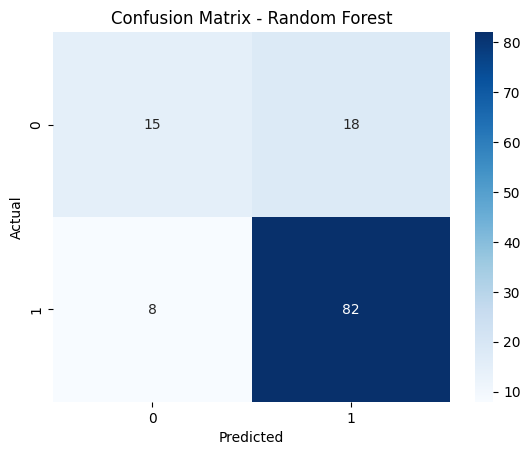

In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Logistic Regression Accuracy:", accuracy_score(y_test,pred1))
print("Random Forest Accuracy:", accuracy_score(y_test,pred2))

print("\nClassification Report (Random Forest):\n")
print(classification_report(y_test, pred2))

cm = confusion_matrix(y_test,pred2)
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
